# 01-1. 데이터 이해 및 진단 (EDA)

이 노트북은 결과보고서 **제1장 「데이터 이해 및 진단」**의 근거 자료입니다.
데이터가 어떤 공장에서, 무엇을, 어떻게 기록한 것인지부터 시작해서
모델을 만들기 전에 꼭 알아야 할 특징과 문제점을 하나씩 확인합니다.

**과제 요약 (KAMP 경진대회 주제 5: 제조 공장 전력사용량 예측)**
- 생산·전력 데이터로 **앞으로의 전력사용량을 예측**하는 AI 모델을 만든다.
- 예측이 크게 틀리는 생산 조건, **최대 전력 피크가 생기는 조건**을 분석한다.
- 생산 일정이나 설비 가동 시점을 조정해 **피크 전력을 낮추는 방법**을 제안한다.

**왜 피크가 중요한가?**
한국전력은 공장의 전기 기본요금을 **15분 동안의 평균 전력 중 가장 높았던 값(최대수요전력)**으로 정합니다.
한 번 높은 피크가 찍히면 그 값이 이후 1년 동안 기본요금에 반영되기 때문에,
피크를 미리 알고 피하는 것이 곧 비용 절감입니다.

## 0. 준비

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

# 한글 글꼴 (Windows: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# 경로: 원본 데이터는 data/raw 폴더에 두고 읽기만 합니다 (수정하지 않음)
DATA_DIR = Path("../data/raw")
DATA_PATH = DATA_DIR / "okm_augumented_2021.csv"
FIG_DIR = Path("../outputs/figures")
TAB_DIR = Path("../outputs/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """보고서에 쓸 그림을 outputs/figures 에 저장"""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

def save_table(df, name):
    """보고서에 쓸 표를 outputs/tables 에 저장 (엑셀에서 한글이 깨지지 않도록 utf-8-sig)"""
    df.to_csv(TAB_DIR / f"{name}.csv", encoding="utf-8-sig")

print("데이터 파일:", DATA_PATH.name, "| 존재:", DATA_PATH.exists())

데이터 파일: okm_augumented_2021.csv | 존재: True


## 1. 데이터 한눈에 보기

### 1-1. 데이터를 불러오고 크기 확인하기
한 행(row)은 **1시간**을 뜻합니다. 그 1시간을 15분씩 4칸으로 나눠서 각 15분 동안의 전력값이 `15분`, `30분`, `45분`, `60분` 열에 들어 있습니다.

In [2]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print(f"행 {raw.shape[0]:,}개 × 열 {raw.shape[1]}개")
print(f"기간: {raw['날짜'].min()} ~ {raw['날짜'].max()}  ({raw['날짜'].nunique()}일 × 24시간 = {raw['날짜'].nunique()*24:,}행)")
raw.head()

행 6,168개 × 열 18개
기간: 20210101 ~ 20210914  (257일 × 24시간 = 6,168행)


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


### 1-2. 각 변수는 무엇을 뜻하나?
가이드북의 변수 정의를 바탕으로, 실제 값의 범위를 함께 정리했습니다.
**'예측할 때 쓸 수 있는가?'** 열은 첫 판단입니다. 최종 판단은 01-2 노트북 3-2 표를 보세요.

In [3]:
desc = {
    "날짜":        ("공장 운영 날짜", "달력 정보로 활용"),
    "시간":        ("공장 운영 시각 (0~23시)", "활용 (오류값 점검 필요)"),
    "15분":        ("0~15분 구간의 전력 (최대수요전력)", "예측 대상"),
    "30분":        ("15~30분 구간의 전력", "예측 대상"),
    "45분":        ("30~45분 구간의 전력", "예측 대상"),
    "60분":        ("45~60분 구간의 전력", "예측 대상"),
    "평균":        ("위 4개 값의 평균", "사용 불가 (정답으로 계산한 값)"),
    "생산량":      ("해당 시점에 생산해야 할 양 (ERP 생산계획)", "검토 필요"),
    "기온":        ("기상청 관측 기온 (℃)", "검토 필요 (미래 값은 예보로만 알 수 있음)"),
    "풍속":        ("기상청 관측 풍속 (m/s)", "검토 필요"),
    "습도":        ("기상청 관측 습도 (%)", "검토 필요"),
    "강수량":      ("기상청 관측 강수량 (mm)", "검토 필요"),
    "전기요금(계절)": ("해당 시점의 전기 요금 단가", "검토 필요"),
    "day":         ("요일 번호", "활용"),
    "d":           ("일", "활용"),
    "m":           ("월", "활용"),
    "공장인원":    ("공장이 보유한 생산력 (가이드북 정의)", "검토 필요"),
    "인건비":      ("주간 대비 야간 인건비 비율", "검토 필요"),
}
var_table = pd.DataFrame(
    [(c, desc[c][0], str(raw[c].dtype),
      (f"{raw[c].min()} ~ {raw[c].max()}" if raw[c].dtype.kind == "i" else f"{raw[c].min():g} ~ {raw[c].max():g}"),
      int(raw[c].isna().sum()), desc[c][1])
     for c in raw.columns],
    columns=["변수", "의미", "자료형", "값 범위", "결측 수", "예측할 때 쓸 수 있는가?"],
).set_index("변수")
save_table(var_table, "t01_변수정의")
var_table

,의미,자료형,값 범위,결측 수,예측할 때 쓸 수 있는가?
변수,,,,,
날짜,공장 운영 날짜,int64,20210101 ~ 20210914,0,달력 정보로 활용
시간,공장 운영 시각 (0~23시),int64,0 ~ 188,0,활용 (오류값 점검 필요)
15분,0~15분 구간의 전력 (최대수요전력),int64,0 ~ 207,0,예측 대상
30분,15~30분 구간의 전력,int64,0 ~ 222,0,예측 대상
45분,30~45분 구간의 전력,int64,0 ~ 218,0,예측 대상
60분,45~60분 구간의 전력,int64,0 ~ 214,0,예측 대상
평균,위 4개 값의 평균,int64,0 ~ 208,0,사용 불가 (정답으로 계산한 값)
생산량,해당 시점에 생산해야 할 양 (ERP 생산계획),int64,0 ~ 9830,0,검토 필요
기온,기상청 관측 기온 (℃),float64,-12 ~ 33.4,0,검토 필요 (미래 값은 예보로만 알 수 있음)


### 1-3. 전체 기간을 그림으로 보기
하루 단위로 **그날의 가장 높은 15분 전력(일 최대 피크)**과 **그날의 생산량 합계**를 함께 그려,
9개월 동안 공장이 어떻게 돌아갔는지 큰 그림을 봅니다.

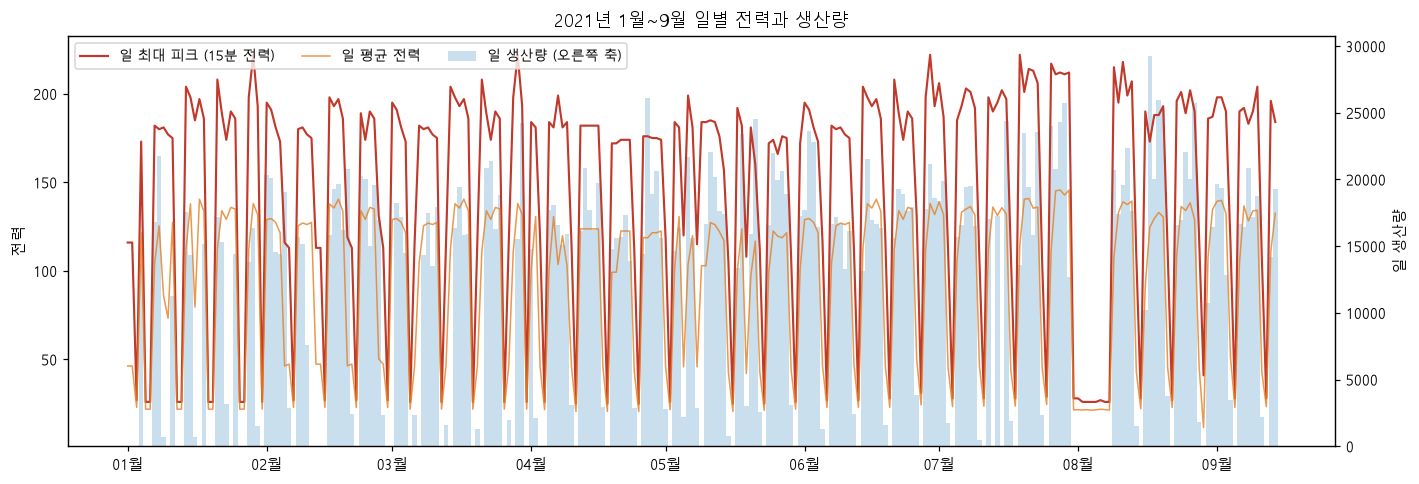

일 최대 피크: 최소 25, 중앙값 181, 최대 222
생산량이 0인 날: 64일 / 257일


In [4]:
df = raw.copy()
df["date"] = pd.to_datetime(df["날짜"].astype(str), format="%Y%m%d")
power_cols = ["15분", "30분", "45분", "60분"]

daily = df.groupby("date").agg(
    일최대피크=("15분", lambda s: df.loc[s.index, power_cols].max(axis=1).max()),
    일평균전력=("평균", "mean"),
    일생산량=("생산량", "sum"),
)

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(daily.index, daily["일최대피크"], color="#c0392b", lw=1.4, label="일 최대 피크 (15분 전력)")
ax1.plot(daily.index, daily["일평균전력"], color="#e67e22", lw=1.0, alpha=0.8, label="일 평균 전력")
ax1.set_ylabel("전력")
ax2 = ax1.twinx()
ax2.bar(daily.index, daily["일생산량"], color="#2980b9", alpha=0.25, width=1.0, label="일 생산량 (오른쪽 축)")
ax2.set_ylabel("일 생산량")
ax1.set_zorder(ax2.get_zorder() + 1); ax1.patch.set_visible(False)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m월"))
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", ncol=3, fontsize=9)
ax1.set_title("2021년 1월~9월 일별 전력과 생산량")
fig.tight_layout()
save_fig(fig, "f01_전체기간_일별전력_생산량")
plt.show()

print(f"일 최대 피크: 최소 {daily['일최대피크'].min()}, 중앙값 {daily['일최대피크'].median():.0f}, 최대 {daily['일최대피크'].max()}")
print(f"생산량이 0인 날: {(daily['일생산량']==0).sum()}일 / {len(daily)}일")

## 2. 데이터 품질 진단

모델을 만들기 전에 **데이터를 믿을 수 있는지** 확인합니다.
먼저 가이드북의 품질 점검 방식으로 점수를 매겨 보고, 이어서 가이드북 방식으로는 드러나지 않는 문제를 하나씩 찾아봅니다.

### 2-1. 가이드북 방식의 품질 점수
가이드북은 6가지 품질 지수(완전성, 유일성, 유효성, 일관성, 정확성, 무결성)에 가중치를 곱해 합산합니다.
같은 방식으로 다시 계산하고, 가이드북 점검이 너무 느슨했던 **유효성**은 실제 허용 범위(예: 시간은 0~23)로 한 번 더 점검했습니다.

In [5]:
P = ["15분", "30분", "45분", "60분"]
n = len(raw)

# 완전성: 결측값 (풍속 3, 강수량 1, 공장인원 17) — 가이드북처럼 0으로 채운 뒤 계산하면 100%
completeness = 100.0
# 유일성: 날짜+시간 조합이 겹치지 않는 비율
key = raw["날짜"] * 100 + raw["시간"]
uniqueness = key.nunique() / n * 100
# 유효성: 가이드북 방식은 각 열의 최솟값과 자기 자신을 비교해 항상 100%
validity_guide = 100.0
# 유효성(엄격): 시간 0~23, 습도 0~100, 전력·생산량 0 이상
valid = raw["시간"].between(0, 23) & raw["습도"].between(0, 100) & (raw[P + ["생산량"]] >= 0).all(axis=1)
validity_strict = valid.mean() * 100
# 일관성: 모든 열이 숫자형인지
# 정확성: '평균' 열이 4개 값의 평균과 맞는지 (반올림 오차 0.5 허용)
consistency = 100.0 if raw.select_dtypes(exclude="number").empty else 0.0
accuracy = ((raw[P].mean(axis=1) - raw["평균"]).abs() <= 0.5).mean() * 100

def integrity(u, v, c):
    return (1 - sum(x < 100 for x in [u, v, c]) / 3) * 100

weights = [20, 10, 20, 20, 20, 10]
guide = [completeness, uniqueness, validity_guide, consistency, accuracy, integrity(uniqueness, validity_guide, consistency)]
strict = [completeness, uniqueness, validity_strict, consistency, accuracy, integrity(uniqueness, validity_strict, consistency)]
quality = pd.DataFrame({"가중치(%)": weights, "가이드북 방식(%)": guide, "엄격한 범위 점검(%)": strict},
                       index=["완전성", "유일성", "유효성", "일관성", "정확성", "무결성"])
quality.loc["종합 품질 점수"] = [100,
    sum(w * s for w, s in zip(weights, guide)) / 100,
    sum(w * s for w, s in zip(weights, strict)) / 100]
save_table(quality.round(2), "t02_품질지수")
quality.round(2)

,가중치(%),가이드북 방식(%),엄격한 범위 점검(%)
완전성,20.0,100.00,100.00
유일성,10.0,99.69,99.69
유효성,20.0,100.00,99.22
일관성,20.0,100.00,100.00
정확성,20.0,100.00,100.00
무결성,10.0,66.67,33.33
종합 품질 점수,100.0,96.64,93.15


**해석**: 가이드북 방식으로는 **약 96.6점**으로 꽤 좋은 데이터처럼 보입니다.
점수를 깎은 원인은 `시간` 열의 잘못된 값(48행)이 거의 전부입니다.
하지만 이 점수는 **'칸이 비었는가, 형식이 맞는가'**만 봅니다.
**값 자체가 진짜인지**는 보지 않기 때문에, 아래에서 따로 확인합니다.

### 2-2. 가이드북이 놓친 문제 1 — 똑같은 날이 반복된다
하루는 15분 칸 96개(24시간 × 4)로 이루어집니다.
**서로 다른 두 날의 96개 전력값이 하나도 빠짐없이 똑같다면**, 실제로 측정한 값이 아니라 다른 날을 복사한 것으로 봐야 합니다.
(파일 이름의 `augumented`도 '증강', 즉 데이터를 인위적으로 늘렸다는 뜻입니다.)

In [6]:
df["hour"] = df.groupby("date").cumcount()          # 하루 24행이 0시부터 순서대로 있으므로 행 순서로 시각을 매김
day_key = df.groupby("date")[P].apply(lambda g: hash(tuple(g.values.ravel())))
same_count = day_key.map(day_key.value_counts())     # 나와 전력 기록이 똑같은 날이 몇 개인지 (나 포함)
dup_day = same_count > 1

print(f"다른 날과 전력 기록이 완전히 같은 날: {dup_day.sum()}일 / {len(dup_day)}일 ({dup_day.mean():.0%})")
print(f"똑같은 날끼리 묶으면 {day_key[dup_day].nunique()}개 묶음")

by_month = pd.DataFrame({"전체 일수": dup_day.groupby(dup_day.index.month).size(),
                         "복사 의심 일수": dup_day.groupby(dup_day.index.month).sum()})
by_month["비율(%)"] = (by_month["복사 의심 일수"] / by_month["전체 일수"] * 100).round(0)
by_month.index = [f"{m}월" for m in by_month.index]
save_table(by_month, "t03_월별_복사의심일")
by_month

다른 날과 전력 기록이 완전히 같은 날: 160일 / 257일 (62%)
똑같은 날끼리 묶으면 45개 묶음


,전체 일수,복사 의심 일수,비율(%)
1월,31,27,87.0
2월,28,28,100.0
3월,31,28,90.0
4월,30,30,100.0
5월,31,17,55.0
6월,30,28,93.0
7월,31,2,6.0
8월,31,0,0.0
9월,14,0,0.0


In [7]:
# 같은 묶음에 속한 날들의 예시 — 요일이 서로 다른 경우가 많다
groups = (pd.DataFrame({"key": day_key[dup_day]})
          .assign(날짜=lambda x: x.index.strftime("%m/%d") + "(" + x.index.day_name().str[:3] + ")")
          .groupby("key")["날짜"].apply(list))
groups = groups[groups.map(len).sort_values(ascending=False).index]
weekday_mixed = sum(len({d[-4:] for d in g}) > 1 for g in groups)
print(f"요일이 서로 다른 날끼리 같은 묶음: {weekday_mixed}개 / {len(groups)}개 묶음\n")
for g in groups.head(5):
    print(" = ".join(g))

# 복사된 날은 무엇까지 같은가? (같은 묶음인 4/12와 5/18 비교)
a, b = pd.to_datetime(["2021-04-12", "2021-05-18"])
same = {c: bool((df.loc[df.date == a, c].values == df.loc[df.date == b, c].values).all())
        for c in P + ["생산량", "공장인원", "기온", "습도"]}
print("\n4/12와 5/18에서 값이 완전히 같은 열:", same)

요일이 서로 다른 날끼리 같은 묶음: 38개 / 45개 묶음

01/05(Tue) = 01/06(Wed) = 01/12(Tue) = 01/13(Wed) = 01/19(Tue) = 01/20(Wed) = 01/26(Tue) = 01/27(Wed) = 01/31(Sun) = 03/05(Fri) = 03/12(Fri) = 03/19(Fri) = 03/26(Fri) = 03/31(Wed) = 05/30(Sun)
01/02(Sat) = 02/05(Fri) = 03/06(Sat) = 03/13(Sat) = 03/20(Sat) = 03/27(Sat) = 06/05(Sat)
04/12(Mon) = 04/13(Tue) = 04/14(Wed) = 04/15(Thu) = 04/16(Fri) = 05/18(Tue)
02/06(Sat) = 02/12(Fri) = 02/13(Sat) = 02/20(Sat) = 02/27(Sat) = 06/12(Sat)
02/07(Sun) = 02/14(Sun) = 02/21(Sun) = 02/28(Sun) = 06/13(Sun)

4/12와 5/18에서 값이 완전히 같은 열: {'15분': True, '30분': True, '45분': True, '60분': True, '생산량': False, '공장인원': False, '기온': False, '습도': False}


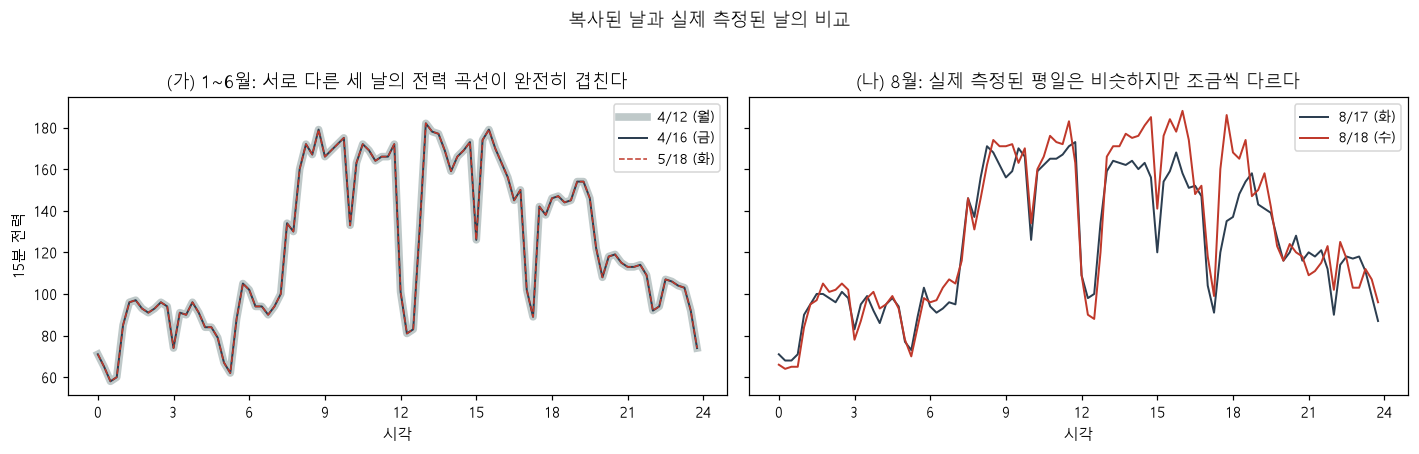

In [8]:
# 그림 2. 복사된 날 vs 실제 측정된 날
slot_x = np.arange(96) / 4      # 15분 칸 → 시각(시간 단위)
def day_slots(d):
    return df.loc[df.date == pd.Timestamp(d), P].values.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
ax = axes[0]
ax.plot(slot_x, day_slots("2021-04-12"), color="#95a5a6", lw=5, alpha=0.6, label="4/12 (월)")
ax.plot(slot_x, day_slots("2021-04-16"), color="#2c3e50", lw=1.3, label="4/16 (금)")
ax.plot(slot_x, day_slots("2021-05-18"), color="#c0392b", lw=1.0, ls="--", label="5/18 (화)")
ax.set_title("(가) 1~6월: 서로 다른 세 날의 전력 곡선이 완전히 겹친다")
ax = axes[1]
ax.plot(slot_x, day_slots("2021-08-17"), color="#2c3e50", lw=1.3, label="8/17 (화)")
ax.plot(slot_x, day_slots("2021-08-18"), color="#c0392b", lw=1.3, label="8/18 (수)")
ax.set_title("(나) 8월: 실제 측정된 평일은 비슷하지만 조금씩 다르다")
for ax in axes:
    ax.set_xlabel("시각"); ax.set_xticks(range(0, 25, 3)); ax.legend(fontsize=9)
axes[0].set_ylabel("15분 전력")
fig.suptitle("복사된 날과 실제 측정된 날의 비교", y=1.02)
fig.tight_layout()
save_fig(fig, "f02_복사된날_비교")
plt.show()

**해석**
- 257일 중 **160일(약 62%)**이 다른 날과 전력 기록이 완전히 같습니다. 거의 모두 **1~6월**에 몰려 있고, 7월에는 7/28과 7/30 한 쌍뿐이며, **8~9월에는 없습니다.**
- 복사된 것은 **전력 기록뿐**입니다. 생산량과 날씨는 날마다 다릅니다(생산량이 같은 경우는 두 날 모두 생산이 0인 휴일뿐).
  즉 복사된 날에는 **다른 날의 전력이 그날의 생산량·날씨와 짝지어져** 있습니다. 그래서 '생산량이 늘면 전력이 어떻게 변하는가' 같은 관계를 배우는 데도 방해가 됩니다.
- 묶음 대부분은 **요일까지 서로 다릅니다**(예: 월요일 기록이 화요일·금요일에 다시 나옴). 그래서 이 구간으로는 '요일별 패턴'을 제대로 배울 수 없습니다.
- 이 구간을 학습이나 평가에 쓰면, 시험 문제와 똑같은 날이 학습 자료에 들어가 있어 **성능이 실제보다 좋게 나옵니다.**

→ 1~6월은 실제 공장 운영을 보여 주는 자료로 보기 어렵습니다.

### 2-3. 가이드북이 놓친 문제 2 — 시간 순서가 깨진 날 (7/13, 7/15)
2-1에서 점수를 깎은 `시간` 열 오류가 어디에 있는지 확인합니다.

In [9]:
bad_time = raw[~raw["시간"].between(0, 23)]
print("시간이 0~23이 아닌 행:", len(bad_time), "개, 날짜:", bad_time["날짜"].unique().tolist())
check = df[df["날짜"] == 20210713][["시간", "평균"]].reset_index(drop=True)
check["평균(작은 순 정렬)"] = np.sort(check["평균"].values)
check.T

시간이 0~23이 아닌 행: 48 개, 날짜: [20210713, 20210715]


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
시간,70,89,90,97,107,108,112,113,115,118,...,136,148,155,159,159,165,171,172,172,188
평균,69,96,112,110,106,143,123,111,102,112,...,150,181,174,143,152,174,175,174,178,188
평균(작은 순 정렬),69,96,102,106,107,110,111,112,112,123,...,143,150,152,174,174,174,175,178,181,188


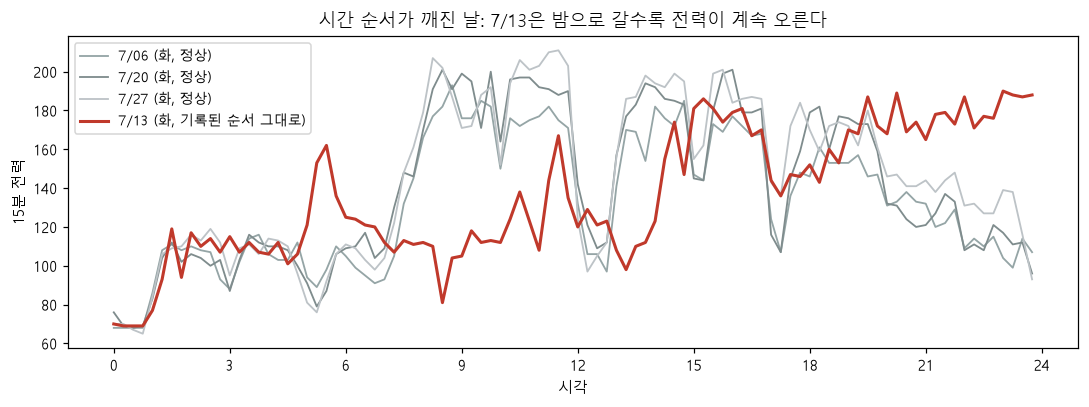

In [10]:
# 그림 3. 7/13(화)의 하루 곡선을 다른 화요일과 비교
fig, ax = plt.subplots(figsize=(10, 3.8))
for d, c in [("2021-07-06", "#95a5a6"), ("2021-07-20", "#7f8c8d"), ("2021-07-27", "#bdc3c7")]:
    ax.plot(slot_x, day_slots(d), color=c, lw=1.2, label=f"{int(d[5:7])}/{d[8:]} (화, 정상)")
ax.plot(slot_x, day_slots("2021-07-13"), color="#c0392b", lw=2, label="7/13 (화, 기록된 순서 그대로)")
ax.set_xlabel("시각"); ax.set_ylabel("15분 전력"); ax.set_xticks(range(0, 25, 3)); ax.legend(fontsize=9)
ax.set_title("시간 순서가 깨진 날: 7/13은 밤으로 갈수록 전력이 계속 오른다")
fig.tight_layout()
save_fig(fig, "f03_시간순서_깨진날")
plt.show()

**해석**
- 7/13과 7/15 이틀, 48행의 `시간` 값이 70, 89, …, 188처럼 0~23이 아닌 숫자입니다.
- 이 숫자들은 **그날 전력값을 작은 순서로 정렬한 것과 거의 같습니다.** 시간 열 자리에 다른 값이 들어가면서 행 순서도 섞인 것으로 보입니다.
- 실제로 7/13 곡선은 정상 화요일과 달리 **밤 11시까지 전력이 계속 오릅니다.** 같은 요일 평균 곡선과의 상관계수는 0.23입니다. 7월 이후 다른 날들은 대부분 0.98 안팎입니다.
- 행 순서를 믿을 수 없어 **어느 값이 몇 시 값인지 복원할 수 없습니다.** 이틀은 분석에서 제외합니다.
  가이드북 예제 코드처럼 행 순서대로 0~23시를 다시 매기면, 이 이틀에는 틀린 시각이 붙습니다.

### 2-4. 가이드북이 놓친 문제 3 — 전력이 0으로 기록된 구간
공장이 쉬는 날에도 조명·공조 등으로 기본 전력(약 25)은 쓰입니다. **0은 '안 썼다'가 아니라 '기록이 안 됐다'**일 가능성이 큽니다.

15분 칸 중 0이 있는 행: 20 개 → {20210828: 7, 20210829: 12, 20210908: 1}
이 구간의 공장인원 결측: 17 행


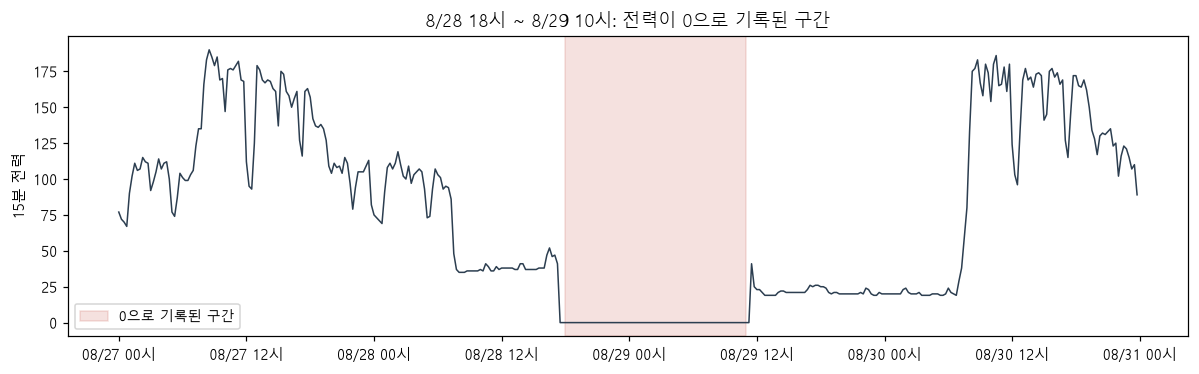

In [11]:
zero_rows = df[(df[P] == 0).any(axis=1)]
print("15분 칸 중 0이 있는 행:", len(zero_rows), "개 →", zero_rows.groupby("날짜").size().to_dict())
print("이 구간의 공장인원 결측:", df.loc[zero_rows.index, "공장인원"].isna().sum(), "행")

seg = df[(df.date >= "2021-08-27") & (df.date <= "2021-08-30")]
t = pd.to_datetime(seg["date"]).values[:, None] + (seg["hour"].values[:, None] * 60 + np.array([0, 15, 30, 45])) * np.timedelta64(1, "m")
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t.ravel(), seg[P].values.ravel(), color="#2c3e50", lw=1)
ax.axvspan(pd.Timestamp("2021-08-28 18:00"), pd.Timestamp("2021-08-29 11:00"), color="#c0392b", alpha=0.15, label="0으로 기록된 구간")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H시"))
ax.set_ylabel("15분 전력"); ax.legend(fontsize=9)
ax.set_title("8/28 18시 ~ 8/29 10시: 전력이 0으로 기록된 구간")
fig.tight_layout()
save_fig(fig, "f04_전력0_구간")
plt.show()

**해석**
- 8/28 18시부터 8/29 10시까지 **17시간 연속으로 전력이 0**입니다(1시간 행 기준. 15분 칸으로 보면 앞뒤로 몇 칸이 더 0입니다). 같은 시간대의 `공장인원`도 비어 있습니다. 앞뒤로는 휴일 수준의 기본 전력(약 25)이 정상적으로 찍힙니다.
- 정전이나 계측 중단으로 보는 것이 자연스럽습니다. 실제 사용량 0으로 학습하면 모델이 잘못 배우므로 **결측(빈 값)으로 처리하고 평가에서도 제외**합니다.
- 9/8 점심에도 15분 칸 2개가 0입니다. 일시적인 기록 누락으로 보고 같은 방식으로 처리합니다.

### 2-5. 가이드북이 놓친 문제 4 — 정답으로 계산된 변수 (`공장인원`)
`공장인원`은 '공장이 보유한 생산력'이라고 정의되어 있지만, 값의 범위(0~48.4, 소수점)가 사람 수로 보기 어렵습니다. 어떻게 만들어졌는지 확인해 봅니다.

In [12]:
has_prod = df["생산량"] > 0
calc = df.loc[has_prod, "생산량"] / df.loc[has_prod, P].sum(axis=1)
match = np.isclose(calc, df.loc[has_prod, "공장인원"], rtol=1e-6)
print(f"공장인원 = 생산량 ÷ (15분+30분+45분+60분 전력 합)  → 일치: {match.sum():,} / {has_prod.sum():,}행")
print("생산량이 0인 시간의 공장인원:", df.loc[~has_prod, "공장인원"].value_counts(dropna=False).to_dict())

공장인원 = 생산량 ÷ (15분+30분+45분+60분 전력 합)  → 일치: 3,511 / 3,511행
생산량이 0인 시간의 공장인원: {0.0: 2640, nan: 17}


**해석**
- `공장인원`은 **생산량을 그 시간의 전력 합으로 나눈 값**과 생산량이 있는 3,511행 모두에서 정확히 일치합니다.
- 즉 예측해야 할 정답(전력)이 이미 섞여 들어간 변수입니다. 입력으로 쓰면 정답을 미리 보고 맞히는 셈이 되므로 **입력에서 제외**합니다.

### 2-6. 그 밖의 변수 점검 — 새로운 정보가 있는가?

In [13]:
print("인건비 (시각별 값):", df.groupby("hour")["인건비"].first().to_dict())
print("전기요금(계절) (월별 값):", df.groupby("m")["전기요금(계절)"].unique().map(list).to_dict())

# 2021년 한전 산업용(을) 고압A 최대부하 시간대 단가 (원/kWh). 출처: 2021.1.1 시행 전기요금표 (한국물가정보 공공요금, data.cmpi.or.kr)
PEAK_PRICE = {"선택Ⅰ": {"여름(6~8월)": 191.6, "봄·가을(3~5, 9~10월)": 109.8, "겨울(11~2월)": 167.2},
              "선택Ⅱ": {"여름(6~8월)": 186.1, "봄·가을(3~5, 9~10월)": 104.3, "겨울(11~2월)": 161.7}}
print("선택Ⅰ 최대부하 단가:", PEAK_PRICE["선택Ⅰ"])
print("데이터의 값이 선택Ⅰ 단가와 모두 일치:", set(df["전기요금(계절)"].unique()) <= set(PEAK_PRICE["선택Ⅰ"].values()))

인건비 (시각별 값): {0: 1.5, 1: 1.5, 2: 1.5, 3: 1.5, 4: 1.5, 5: 1.5, 6: 1.5, 7: 1.5, 8: 1.5, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.5, 19: 1.5, 20: 1.5, 21: 1.5, 22: 1.5, 23: 1.5}
전기요금(계절) (월별 값): {1: [np.float64(109.8)], 2: [np.float64(109.8)], 3: [np.float64(167.2)], 4: [np.float64(167.2)], 5: [np.float64(167.2)], 6: [np.float64(191.6)], 7: [np.float64(191.6)], 8: [np.float64(191.6)], 9: [np.float64(167.2)]}
선택Ⅰ 최대부하 단가: {'여름(6~8월)': 191.6, '봄·가을(3~5, 9~10월)': 109.8, '겨울(11~2월)': 167.2}
데이터의 값이 선택Ⅰ 단가와 모두 일치: True


**해석**
- `인건비`는 **9~17시 1.0, 그 외 시간 1.5**로 고정되어 있습니다. 주간/야간을 나타내는 표시일 뿐 시각 정보와 같은 내용입니다. 야간·연장 근무의 인건비 할증(1.5배)으로 읽을 수 있습니다.
- `전기요금(계절)`은 **월마다 하나의 값**(1~2월 109.8, 3~5월·9월 167.2, 6~8월 191.6)입니다.
  - 세 값은 2021년 한전 **산업용(을) 고압A 선택Ⅰ의 '최대부하 시간대' 단가**(여름 191.6, 봄·가을 109.8, 겨울 167.2원/kWh)와 정확히 같습니다. 그래서 이 공장의 계약은 **산업용(을) 선택Ⅰ**으로 보는 것이 자연스럽습니다. 4장의 요금 계산은 이 계약을 기본으로 합니다.
  - 다만 **계절이 어긋나 붙어 있습니다.** 1~2월(겨울)에 봄·가을 값, 3~5월과 9월(봄·가을)에 겨울 값이 들어 있습니다. 실제 요금표와 맞지 않으므로 이 열의 값을 그대로 쓰지 않고, 요금 계산에는 요금표를 직접 씁니다.
- 두 변수 모두 시각·월과 겹치는 정보라 예측에 새로 더해 주는 것은 없습니다. 대신 **요금 계약 종류를 알려 주는 단서**이고, 4장 비용 계산에 씁니다.

### 2-7. 진단 요약과 처리 방침
지금까지의 진단을 한 표로 정리합니다. 이 표가 **"왜 7/1~9/14 데이터만 쓰는가"**의 근거입니다.

In [14]:
summary = pd.DataFrame([
    ["똑같은 날의 반복", "160일(62%)이 다른 날과 전력 기록이 완전히 같음. 1~6월에 집중, 8~9월은 없음",
     "학습·평가에 쓰면 성능이 부풀려지고, 요일 패턴도 왜곡됨", "1~6월 제외, 7/1 이후만 사용 (7/28·7/30 한 쌍은 평가에서 제외)"],
    ["시간 순서가 깨진 날", "7/13, 7/15의 시간 열에 정렬된 전력값이 들어감, 하루 곡선도 비정상",
     "몇 시 값인지 알 수 없음", "두 날 제외"],
    ["전력 0 기록", "8/28 18시~8/29 10시 17시간 연속 0 (+9/8 12시 15분 칸 두 개)",
     "실제 사용량이 아닌 계측 중단으로 판단", "결측으로 처리, 평가에서 제외"],
    ["정답에서 계산된 변수", "공장인원 = 생산량 ÷ 전력 합 (3,511행 모두 일치)",
     "입력에 쓰면 정답을 미리 보는 셈", "입력에서 제외"],
    ["정답의 평균", "평균 = 15·30·45·60분 값의 평균", "입력에 쓰면 정답을 미리 보는 셈", "입력에서 제외"],
    ["시간대·계절 표시 변수", "인건비 = 주간/야간(1.0/1.5), 전기요금 = 월별 고정값(산업용(을) 선택Ⅰ 최대부하 단가와 일치, 계절은 어긋남)",
     "시각·월과 같은 정보, 전기요금 열은 계절 표기가 틀림", "예측 입력에서 빼고, 계약 종류(선택Ⅰ) 판단에만 사용. 요금 계산은 요금표로"],
], columns=["문제", "발견 내용", "영향", "처리 방침"])
save_table(summary.set_index("문제"), "t04_품질진단_요약")

use = df[(df.date >= "2021-07-01") & (~df["날짜"].isin([20210713, 20210715]))]
print(f"분석에 쓰는 기간: 2021-07-01 ~ 2021-09-14 → {use['date'].nunique()}일 "
      f"(15분 칸 {use['date'].nunique() * 96:,}개, 7/13·7/15 제외)")
summary

분석에 쓰는 기간: 2021-07-01 ~ 2021-09-14 → 74일 (15분 칸 7,104개, 7/13·7/15 제외)


,문제,발견 내용,영향,처리 방침
0,똑같은 날의 반복,"160일(62%)이 다른 날과 전력 기록이 완전히 같음. 1~6월에 집중, 8~9월...","학습·평가에 쓰면 성능이 부풀려지고, 요일 패턴도 왜곡됨","1~6월 제외, 7/1 이후만 사용 (7/28·7/30 한 쌍은 평가에서 제외)"
1,시간 순서가 깨진 날,"7/13, 7/15의 시간 열에 정렬된 전력값이 들어감, 하루 곡선도 비정상",몇 시 값인지 알 수 없음,두 날 제외
2,전력 0 기록,8/28 18시~8/29 10시 17시간 연속 0 (+9/8 12시 15분 칸 두 개),실제 사용량이 아닌 계측 중단으로 판단,"결측으로 처리, 평가에서 제외"
3,정답에서 계산된 변수,"공장인원 = 생산량 ÷ 전력 합 (3,511행 모두 일치)",입력에 쓰면 정답을 미리 보는 셈,입력에서 제외
4,정답의 평균,평균 = 15·30·45·60분 값의 평균,입력에 쓰면 정답을 미리 보는 셈,입력에서 제외
5,시간대·계절 표시 변수,"인건비 = 주간/야간(1.0/1.5), 전기요금 = 월별 고정값(산업용(을) 선택Ⅰ...","시각·월과 같은 정보, 전기요금 열은 계절 표기가 틀림","예측 입력에서 빼고, 계약 종류(선택Ⅰ) 판단에만 사용. 요금 계산은 요금표로"


**정리**: 가이드북 방식의 품질 점수는 96.6점이었지만, 실제로는 **전체 기간의 약 62%가 다른 날과 전력 기록이 똑같은 날**이었습니다.
그래서 이 분석은 실제로 측정된 것으로 확인되는 **2021년 7월 1일 ~ 9월 14일(74일)**을 사용합니다.
데이터 양은 줄지만, **성능을 부풀리지 않고 정직하게 평가**할 수 있습니다.
이 점은 보고서 1장의 핵심 메시지이자 5장 '차별성'에서도 강조할 부분입니다.

## 3. 실제 측정 구간(7/1~9/14)의 패턴 분석

2장에서 정한 74일만 가지고 공장이 **언제, 얼마나** 전기를 쓰는지 살펴봅니다.
이 결과로 무엇을 예측할지, 어떤 정보를 입력으로 쓸지를 정합니다.

### 3-1. 분석용 15분 데이터 만들기
1시간 1행을 **15분 1행**으로 펼칩니다. 한전 요금이 15분 단위로 매겨지기 때문에, 분석과 예측도 15분 단위로 합니다.
- 7/13, 7/15는 빈 값으로 둡니다. 행을 아예 지우지 않는 이유는 15분 간격이 끊기지 않게 하기 위해서입니다.
- 전력 0은 빈 값으로 바꿉니다.
- 하루의 종류(평일 가동, 토요일, 일요일, 휴무)를 표시합니다. 여기서는 달력과 하계 휴무로 임시 구분하며, 최종 구분은 01-2 노트북에서 생산계획으로 정합니다.

In [15]:
MINUTE = {"15분": 0, "30분": 15, "45분": 30, "60분": 45}
period = df[df["date"] >= "2021-07-01"].copy()
slots = period.melt(id_vars=["date", "hour", "생산량", "기온"], value_vars=P, var_name="칸", value_name="전력")
slots["ts"] = slots["date"] + pd.to_timedelta(slots["hour"], "h") + pd.to_timedelta(slots["칸"].map(MINUTE), "m")
slots = slots.sort_values("ts").set_index("ts")[["전력", "생산량", "기온"]]

slots.loc[slots.index.normalize().isin(pd.to_datetime(["2021-07-13", "2021-07-15"])), "전력"] = np.nan  # 시간 순서가 깨진 날
slots.loc[slots["전력"] == 0, "전력"] = np.nan                                                         # 계측 중단

# 하루의 종류: 7/31(토)~8/8(일)은 일주일 넘게 기본 전력만 쓰이므로 하계 휴무로 표시
summer_off = pd.date_range("2021-07-31", "2021-08-08")
def day_type(d):
    if d in summer_off: return "휴무"
    return {5: "토요일", 6: "일요일"}.get(d.dayofweek, "평일")
slots["date"] = slots.index.normalize()
slots["요일"] = slots.index.dayofweek
slots["시각"] = slots.index.hour + slots.index.minute / 60
slots["일종류"] = slots["date"].map(day_type)

print(f"15분 칸: {len(slots):,}개 (빈 값 {slots['전력'].isna().sum()}개)")
print(slots.groupby("일종류")["date"].nunique().rename("일수").to_dict())

15분 칸: 7,296개 (빈 값 266개)
{'일요일': 9, '토요일': 9, '평일': 49, '휴무': 9}


### 3-2. 하루 전력 곡선 — 공장은 하루를 어떻게 보내나?

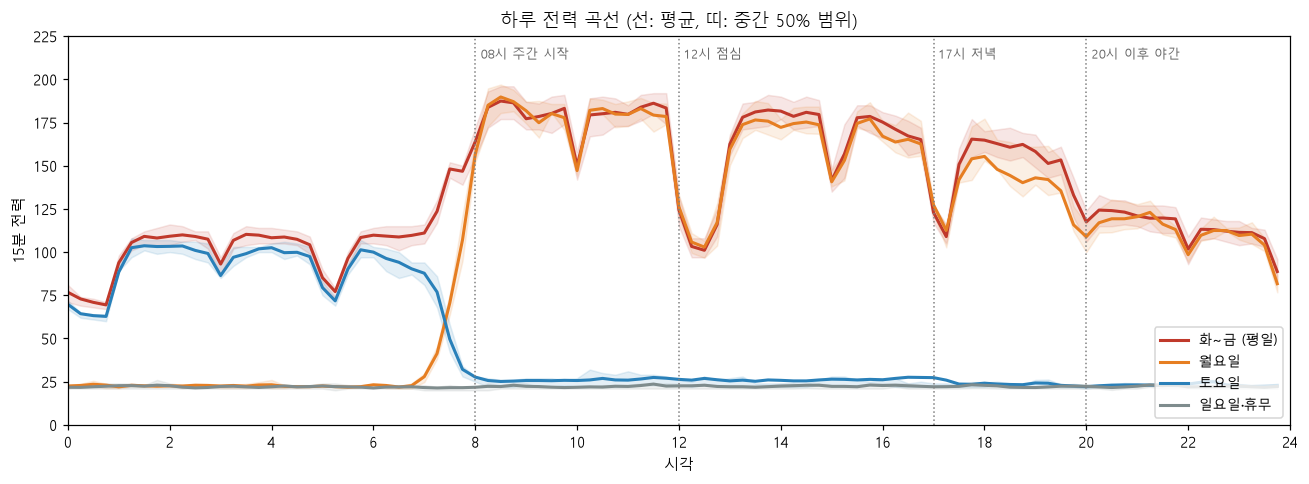

시,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
화~금 (평일),72.0,104.0,109.0,105.0,107.0,92.0,109.0,132.0,180.0,180.0,...,180.0,164.0,170.0,137.0,163.0,149.0,122.0,120.0,110.0,105.0
월요일,23.0,22.0,23.0,23.0,22.0,22.0,23.0,62.0,180.0,179.0,...,174.0,161.0,165.0,134.0,147.0,134.0,116.0,118.0,108.0,101.0
토요일,65.0,99.0,102.0,96.0,100.0,86.0,95.0,62.0,26.0,26.0,...,26.0,26.0,27.0,25.0,24.0,23.0,23.0,23.0,24.0,23.0
일요일·휴무,22.0,23.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,...,23.0,22.0,23.0,22.0,22.0,22.0,22.0,23.0,22.0,22.0


In [16]:
WD = ["월", "화", "수", "목", "금", "토", "일"]
work = slots[slots["일종류"] == "평일"]
curves = {
    "화~금 (평일)": work[work["요일"].between(1, 4)],
    "월요일": work[work["요일"] == 0],
    "토요일": slots[slots["일종류"] == "토요일"],
    "일요일·휴무": slots[slots["일종류"].isin(["일요일", "휴무"])],
}
colors = ["#c0392b", "#e67e22", "#2980b9", "#7f8c8d"]
fig, ax = plt.subplots(figsize=(12, 4.5))
for (name, g), c in zip(curves.items(), colors):
    prof = g.groupby("시각")["전력"]
    ax.plot(prof.mean().index, prof.mean().values, color=c, lw=2, label=name)
    ax.fill_between(prof.mean().index, prof.quantile(0.25), prof.quantile(0.75), color=c, alpha=0.12)
for x, txt in [(8, "08시 주간 시작"), (12, "12시 점심"), (17, "17시 저녁"), (20, "20시 이후 야간")]:
    ax.axvline(x, color="gray", ls=":", lw=1)
    ax.text(x + 0.1, 212, txt, fontsize=8.5, color="dimgray")
ax.set_xticks(range(0, 25, 2)); ax.set_xlim(0, 24); ax.set_ylim(0, 225)
ax.set_xlabel("시각"); ax.set_ylabel("15분 전력"); ax.legend(loc="lower right", fontsize=9)
ax.set_title("하루 전력 곡선 (선: 평균, 띠: 중간 50% 범위)")
fig.tight_layout()
save_fig(fig, "f05_하루_전력곡선")
plt.show()

hourly_prof = pd.DataFrame({k: v.groupby(v.index.hour)["전력"].mean().round(0) for k, v in curves.items()})
hourly_prof.index.name = "시"
save_table(hourly_prof, "t05_시각별_평균전력")
hourly_prof.T

**해석**
- **밤낮으로 쉬지 않고 돌아가는 공장**입니다. 평일 주간(08~17시)에 175~190으로 가장 많이 쓰고, 17~20시에는 150~165, 20시 이후 야간에는 105~125 수준으로 설비가 계속 돌아갑니다.
- **점심(12시)과 저녁(17시)에 전력이 뚝 떨어졌다가** 다시 올라갑니다. 작업이 일제히 멈췄다 재개되는 시점입니다.
  10시·15시, 새벽 3시·5시에도 짧게 떨어지는데, 정해진 **휴식 시간**으로 보입니다.
- **월요일 새벽(0~7시)은 꺼져 있습니다.** 일요일에 쉬었기 때문에 야간 근무가 없고, 08시에 한꺼번에 가동을 시작합니다.
- **토요일은 오전 7시까지만** 전력이 높습니다. 금요일 야간 근무가 토요일 아침에 끝나고, 그 뒤로는 쉽니다.
- 일요일과 휴무일에는 하루 종일 **기본 전력(약 20~25)**만 쓰입니다.

→ 전력은 **'오늘이 어떤 날인가 + 지금 몇 시인가'**로 대부분 결정됩니다.

### 3-3. 요일 × 시각 한눈에 보기

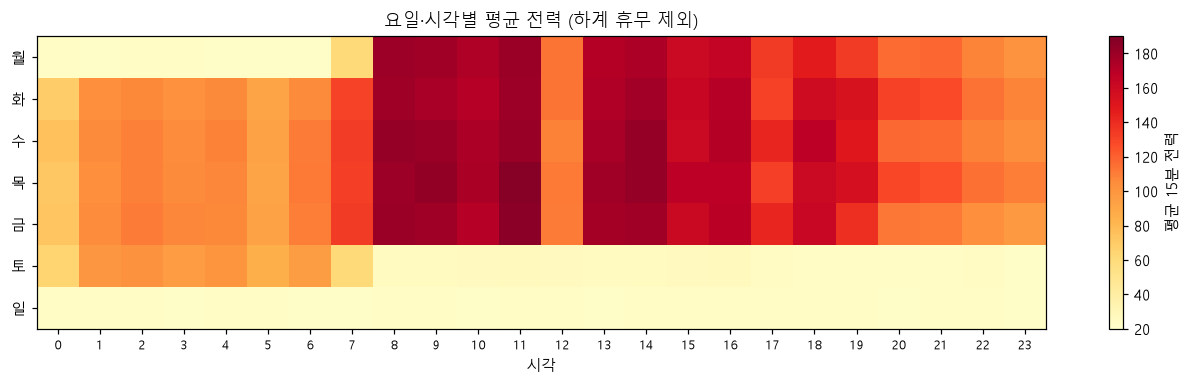

In [17]:
no_off = slots[slots["일종류"] != "휴무"]
heat = no_off.pivot_table(index="요일", columns=no_off.index.hour, values="전력", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 3.6))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd", vmin=20, vmax=190)
ax.set_yticks(range(7)); ax.set_yticklabels(WD)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24), fontsize=8)
ax.set_xlabel("시각"); fig.colorbar(im, ax=ax, label="평균 15분 전력")
ax.set_title("요일·시각별 평균 전력 (하계 휴무 제외)")
fig.tight_layout()
save_fig(fig, "f06_요일x시각_히트맵")
plt.show()

**해석**: 그림 5의 내용이 한 장에 보입니다. 평일 주간에는 진한 빨간 띠가, 월요일 새벽과 토요일 오전 이후에는 빈칸이 나타납니다.
**12시 점심의 세로 줄무늬**도 뚜렷합니다. 피크 관리에서 주목할 곳은 이 빨간 띠(평일 08~16시)입니다.

### 3-4. 하루 종류별 달력 — 공장이 쉰 날은?
평일인데 쉰 날, 공휴일인데 일한 날이 있는지 확인합니다. 공휴일 달력만으로 '쉬는 날'을 정하면 틀릴 수 있기 때문입니다.

In [18]:
daily3 = slots.groupby("date").agg(일종류=("일종류", "first"), 최대=("전력", "max"), 평균=("전력", "mean"))
daily3["일생산량"] = period.groupby("date")["생산량"].sum()
daily3["요일"] = daily3.index.dayofweek.map(lambda i: WD[i])
special = daily3.loc[pd.to_datetime(["2021-07-30", "2021-07-31", "2021-08-02", "2021-08-06", "2021-08-09", "2021-08-15", "2021-08-16", "2021-08-17"])]
print("하계 휴무로 표시한 기간: 7/31(토) ~ 8/8(일), 9일")
special[["요일", "일종류", "최대", "평균", "일생산량"]].round(1)

하계 휴무로 표시한 기간: 7/31(토) ~ 8/8(일), 9일


,요일,일종류,최대,평균,일생산량
2021-07-30,금,평일,212.0,145.6,12688
2021-07-31,토,휴무,28.0,21.4,0
2021-08-02,월,휴무,26.0,21.4,0
2021-08-06,금,휴무,27.0,21.8,0
2021-08-09,월,평일,215.0,107.6,20689
2021-08-15,일,일요일,28.0,21.9,0
2021-08-16,월,평일,190.0,91.4,10238
2021-08-17,화,평일,173.0,124.5,29279


**해석**
- **7/31~8/8(9일)은 하계 휴무**입니다. 평일인데도 하루 최대 전력이 26~28로 일요일과 같고, 생산량도 0입니다.
- **8/16(월)은 광복절 대체공휴일이지만 공장은 가동**했습니다(최대 190). 다만 평균은 다른 월요일보다 낮습니다.
- 그래서 '공휴일 달력'을 그대로 입력으로 쓰면 틀린 정보를 주게 됩니다. 공장의 **실제 가동 계획**(생산 계획이 있는 날인지)을 쓰는 편이 정확합니다.

### 3-5. 피크는 언제 생기나?
측정 구간 전체 15분 칸 중 **상위 10%(178 초과)**(전력이 가장 높은 10%)를 '고부하 구간'으로 보고, 언제 몰려 있는지 봅니다.

상위 10% 기준: 178 초과 (상위 5%: 188 초과, 최댓값 222)
고부하 구간 699칸 중 평일 주간(월~금 08~16시): 96%


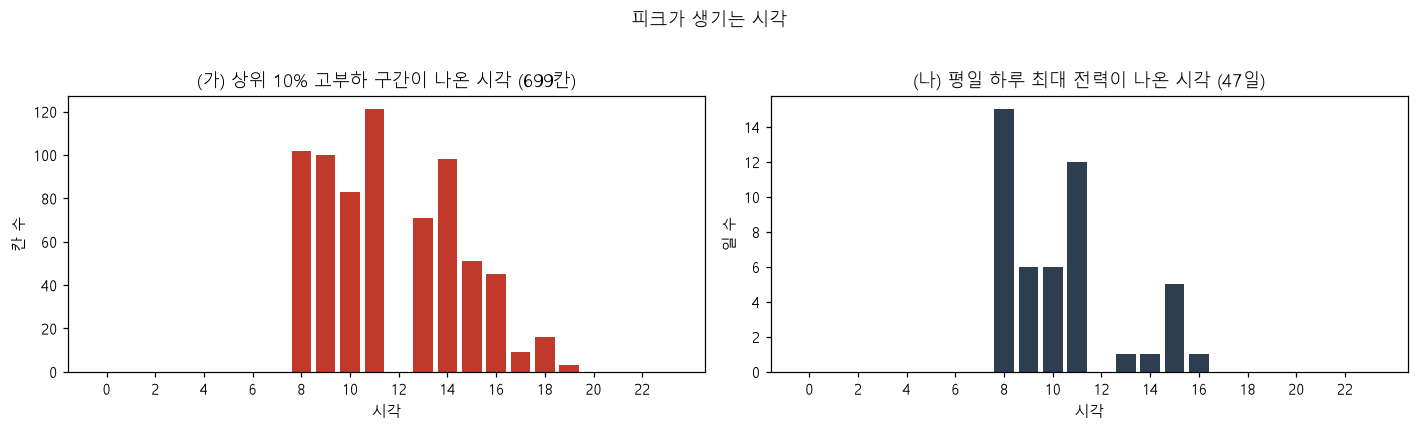

요일별 고부하 칸 수: {'월': 140, '화': 122, '수': 144, '목': 149, '금': 144}
측정 구간 상위 4칸: ['07/19(월) 11:15 222', '08/11(수) 08:30 218', '07/26(월) 08:15 217', '08/09(월) 08:30 215']
전체 기간 최댓값 222이 나온 시각: [[20210129, 8], [20210329, 8], [20210629, 8], [20210719, 11]] | 이보다 큰 값: 없음


In [19]:
thr90 = slots["전력"].quantile(0.90)
thr95 = slots["전력"].quantile(0.95)
high = slots[slots["전력"] > thr90]
print(f"상위 10% 기준: {thr90:.0f} 초과 (상위 5%: {thr95:.0f} 초과, 최댓값 {slots['전력'].max():.0f})")
print(f"고부하 구간 {len(high)}칸 중 평일 주간(월~금 08~16시): {((high['요일'] < 5) & high.index.hour.isin(range(8, 17))).mean():.0%}")

daily_max_hour = work.dropna(subset=["전력"]).groupby("date")["전력"].idxmax().dt.hour
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
cnt = high.index.hour.value_counts().reindex(range(24), fill_value=0)
axes[0].bar(cnt.index, cnt.values, color="#c0392b")
axes[0].set_title(f"(가) 상위 10% 고부하 구간이 나온 시각 ({len(high)}칸)")
axes[0].set_xlabel("시각"); axes[0].set_ylabel("칸 수"); axes[0].set_xticks(range(0, 24, 2))
cnt2 = daily_max_hour.value_counts().reindex(range(24), fill_value=0)
axes[1].bar(cnt2.index, cnt2.values, color="#2c3e50")
axes[1].set_title(f"(나) 평일 하루 최대 전력이 나온 시각 ({len(daily_max_hour)}일)")
axes[1].set_xlabel("시각"); axes[1].set_ylabel("일 수"); axes[1].set_xticks(range(0, 24, 2))
fig.suptitle("피크가 생기는 시각", y=1.02)
fig.tight_layout()
save_fig(fig, "f07_피크_발생시각")
plt.show()
print("요일별 고부하 칸 수:", {WD[k]: v for k, v in high["요일"].value_counts().sort_index().items()})

# 가장 높은 칸들은 어떤 날인가? (월요일 = 전날 쉰 날)
top = slots["전력"].nlargest(4)
print("측정 구간 상위 4칸:", [f"{t:%m/%d}({WD[t.dayofweek]}) {t:%H:%M} {v:.0f}" for t, v in top.items()])
# 222는 기록상 최댓값: 몇 번 나오고, 넘는 값은 있는가?
hit = df.loc[(df[P] == df[P].max().max()).any(axis=1), ["날짜", "hour"]]
print(f"전체 기간 최댓값 {df[P].max().max():.0f}이 나온 시각:", hit.values.tolist(), "| 이보다 큰 값: 없음")

**해석**
- 고부하 구간은 **거의 모두 평일 주간(08~16시)**에 생깁니다. 특히 **오전 08~11시**에 가장 많습니다.
- 하루 최대 전력은 **08시(주간 가동 직후)**와 **11시(점심 직전)**에 가장 자주 나옵니다. 여러 설비가 동시에 돌기 시작하거나, 오전 작업이 몰리는 시간입니다.
- 요일별로는 고르게 나와서 **월요일도 피크 위험이 낮지 않습니다**(새벽은 꺼져 있다가 08시에 한꺼번에 켜지기 때문).
- 특히 **가장 높은 4칸 중 3칸(7/19 222, 7/26 217, 8/9 215)이 월요일**입니다. 주말에 쉬었다가 다시 돌리는 날은 피크를 따로 조심해야 합니다(4장 '주의일').
- 측정 구간 최대 222는 **전체 기간의 최댓값이기도 하고, 이를 넘는 값이 한 번도 없습니다.** 222가 나온 4일 중 3일(1/29, 3/29, 6/29)은 복사된 날이라 실제 사건은 7/19 하나입니다. 222가 실제 최대인지, 계측 장비의 상한인지는 이 데이터로 구분할 수 없어 한계로 남깁니다.

→ 피크 저감의 핵심 시간대는 **평일 오전 08:00~12:00**입니다. 4장 '피크 저감 방안'에서 이 시간대의 가동을 분산하는 방법을 다룰 수 있습니다.

### 3-6. 직전 값과 얼마나 닮았나? — 예측을 얼마나 앞서 할 수 있나
'15분 전 값', '1시간 전 값', '어제 같은 시각', '지난주 같은 시각'을 그대로 예측값으로 쓴다면 얼마나 맞을지 확인합니다.
이것이 가장 단순한 예측 방법이자, 앞으로 만들 모델이 **반드시 넘어야 할 기준**입니다.

In [20]:
k = slots["전력"]
naive = pd.DataFrame([
    (name, k.corr(k.shift(lag)), (k - k.shift(lag)).abs().mean())
    for name, lag in [("15분 전 값", 1), ("1시간 전 값", 4), ("어제 같은 시각", 96), ("지난주 같은 시각", 672)]
], columns=["그대로 썼을 때", "상관계수", "평균 절대오차(MAE)"]).set_index("그대로 썼을 때").round(3)
save_table(naive, "t06_단순예측_비교")
naive

,상관계수,평균 절대오차(MAE)
그대로 썼을 때,,
15분 전 값,0.975,7.861
1시간 전 값,0.897,16.723
어제 같은 시각,0.506,35.464
지난주 같은 시각,0.663,25.162


**해석**
- **15분 전 값**은 실제 값과 거의 같습니다(상관 0.975, 평균 절대오차(MAE) 약 7.9). 바로 다음 15분은 지금 값만 봐도 잘 맞습니다.
- **1시간만 앞서도** 오차가 두 배 넘게 커집니다(약 16.7). 가동 시작·점심·저녁처럼 전력이 급변하는 순간을 놓치기 때문입니다.
- **어제 같은 시각**은 오히려 더 나쁩니다(약 35.5). 금요일→토요일, 일요일→월요일처럼 하루 종류가 바뀌는 날이 많기 때문입니다.
- **지난주 같은 시각**은 요일이 맞아서 어제보다 낫지만(약 25.2), 하계 휴무 같은 일정 변화에 약합니다.

→ **예측 시점을 언제로 잡느냐**가 가장 중요한 설계 결정입니다.
15분 앞 예측은 쉽지만 대응할 시간이 거의 없고, 하루 앞 예측은 어렵지만 생산 일정을 조정할 시간이 있습니다.
과제는 '생산 일정·설비 가동 시점 조정'을 요구하므로, **몇 시간~하루 앞 예측**이 의미 있습니다. 그래서 하루 앞 예측을 주 예측으로, 1시간 앞 예측을 보조로 정했습니다(01-2 노트북).

### 3-7. 생산량과 전력의 관계

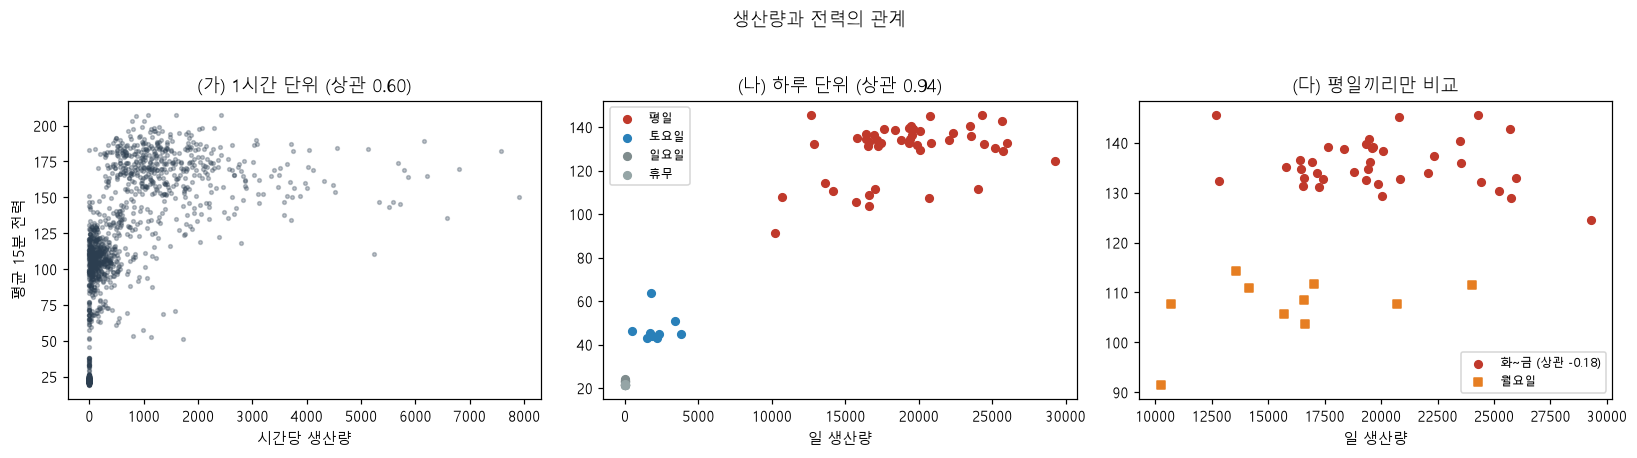

평일 전체 상관 0.37 / 월요일 빼고 화~금만 -0.18
화~금 생산량 하위 25% 날의 평균 전력 135.0, 상위 25% 날 135.1
시각별 평균 생산량: {0: 101, 1: 135, 2: 126, 3: 130, 4: 102, 5: 103, 6: 148, 7: 678, 8: 515, 9: 767, 10: 798, 11: 913, 12: 221, 13: 965, 14: 1199, 15: 965, 16: 1238, 17: 558, 18: 948, 19: 1503, 20: 65, 21: 72, 22: 85, 23: 89}


In [21]:
hourly = period.assign(전력=period[P].mean(axis=1).where(period[P].min(axis=1) > 0))
hourly = hourly[~hourly["날짜"].isin([20210713, 20210715])]
day_p = hourly.groupby("date").agg(평균전력=("전력", "mean"), 일생산량=("생산량", "sum"))
day_p["일종류"] = day_p.index.map(day_type)
weekday_p = day_p[day_p["일종류"] == "평일"]
tuefri = weekday_p[weekday_p.index.dayofweek > 0]
monday = weekday_p[weekday_p.index.dayofweek == 0]

r_hour = hourly["전력"].corr(hourly["생산량"])
r_day = day_p["평균전력"].corr(day_p["일생산량"])
r_weekday = weekday_p["평균전력"].corr(weekday_p["일생산량"])
r_tuefri = tuefri["평균전력"].corr(tuefri["일생산량"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(hourly["생산량"], hourly["전력"], s=6, alpha=0.3, color="#2c3e50")
axes[0].set_title(f"(가) 1시간 단위 (상관 {r_hour:.2f})"); axes[0].set_xlabel("시간당 생산량"); axes[0].set_ylabel("평균 15분 전력")
for t, c in zip(["평일", "토요일", "일요일", "휴무"], ["#c0392b", "#2980b9", "#7f8c8d", "#95a5a6"]):
    g = day_p[day_p["일종류"] == t]
    axes[1].scatter(g["일생산량"], g["평균전력"], s=25, color=c, label=t)
axes[1].set_title(f"(나) 하루 단위 (상관 {r_day:.2f})"); axes[1].set_xlabel("일 생산량"); axes[1].legend(fontsize=8)
axes[2].scatter(tuefri["일생산량"], tuefri["평균전력"], s=25, color="#c0392b", label=f"화~금 (상관 {r_tuefri:.2f})")
axes[2].scatter(monday["일생산량"], monday["평균전력"], s=25, color="#e67e22", marker="s", label="월요일")
axes[2].set_title("(다) 평일끼리만 비교"); axes[2].set_xlabel("일 생산량"); axes[2].legend(fontsize=8)
fig.suptitle("생산량과 전력의 관계", y=1.03)
fig.tight_layout()
save_fig(fig, "f08_생산량과_전력")
plt.show()

q1, q3 = tuefri["일생산량"].quantile([0.25, 0.75])
print(f"평일 전체 상관 {r_weekday:.2f} / 월요일 빼고 화~금만 {r_tuefri:.2f}")
print(f"화~금 생산량 하위 25% 날의 평균 전력 {tuefri.loc[tuefri['일생산량'] <= q1, '평균전력'].mean():.1f}, "
      f"상위 25% 날 {tuefri.loc[tuefri['일생산량'] >= q3, '평균전력'].mean():.1f}")
prod_hour = hourly.groupby("hour")["생산량"].mean().round(0)
print("시각별 평균 생산량:", prod_hour.astype(int).to_dict())

**해석**
- 하루 단위로 보면 생산량과 전력의 상관이 매우 높아 보입니다(그림 8 나). 하지만 이는 **'생산하는 날은 전기를 많이 쓰고, 쉬는 날은 적게 쓴다'**는 가동/휴무의 차이일 뿐입니다.
- 평일끼리만 보면 상관이 0.37로 약해지는데, 이것도 **월요일 때문**입니다. 월요일은 새벽에 꺼져 있어 평균 전력이 낮고, 생산량도 적은 편입니다.
  **월요일을 빼고 화~금끼리 비교하면 관계가 사라집니다**(상관 −0.18). 생산량 하위 25% 날과 상위 25% 날의 평균 전력이 둘 다 약 135로 같습니다(그림 8 다).
  생산량이 많은 날이라고 전기를 더 쓰지는 않는다는 뜻입니다.
- 1시간 단위로도 관계가 흐릿합니다(그림 8 가). 시각별로 보면 생산량은 20시 이후 거의 0으로 기록되는데, 야간에도 전력은 100 안팎으로 쓰입니다.
  `생산량`은 실제 설비 가동량이라기보다 **ERP에 입력된 계획·실적 기록**에 가까워 보입니다(보고서 1-5의 가정·한계 참고).

→ 생산량은 **'오늘 공장을 돌리는가'**를 알려 주는 정보로는 쓸모가 있습니다. 하지만 **'얼마나 많이 쓰는가'**를 설명하는 힘은 약합니다.
예측 모델에서는 가동 여부 표시로 쓰는 것을 검토합니다.

### 3-8. 기온과 전력의 관계
여름철에는 냉방 설비가 전력을 더 쓸 수 있습니다. 시각과 요일의 영향을 빼고 보기 위해 **화~금 주간(09~16시, 점심 제외)**만 비교합니다.

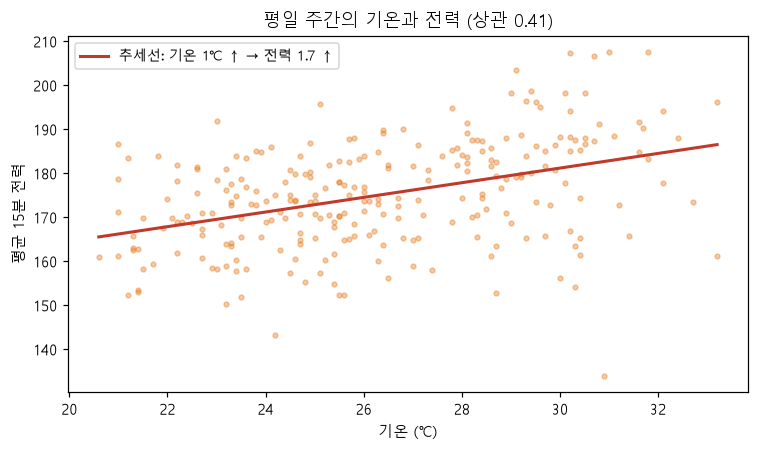

비교한 시간: 259개, 기온 범위 20.6~33.2℃


In [22]:
cmp = hourly[(hourly["date"].dt.dayofweek.between(1, 4)) & hourly["hour"].isin([9, 10, 11, 13, 14, 15, 16])
             & (hourly["date"].map(day_type) == "평일")].dropna(subset=["전력"])
r_temp = cmp["전력"].corr(cmp["기온"])
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(cmp["기온"], cmp["전력"], s=10, alpha=0.4, color="#e67e22")
b = np.polyfit(cmp["기온"], cmp["전력"], 1)
xs = np.linspace(cmp["기온"].min(), cmp["기온"].max(), 50)
ax.plot(xs, np.polyval(b, xs), color="#c0392b", lw=2, label=f"추세선: 기온 1℃ ↑ → 전력 {b[0]:.1f} ↑")
ax.set_xlabel("기온 (℃)"); ax.set_ylabel("평균 15분 전력"); ax.legend(fontsize=9)
ax.set_title(f"평일 주간의 기온과 전력 (상관 {r_temp:.2f})")
fig.tight_layout()
save_fig(fig, "f09_기온과_전력")
plt.show()
print(f"비교한 시간: {len(cmp)}개, 기온 범위 {cmp['기온'].min()}~{cmp['기온'].max()}℃")

**해석**
- 같은 평일 주간(화~금 09~16시, 점심 제외)끼리 비교하면 **기온이 높을수록 전력이 조금 더 높습니다**(그림 9). 추세선 기준으로 기온이 1℃ 오를 때 전력이 약 1.7 높아집니다. 여름철 냉방 부하가 더해졌을 수 있습니다. 다만 더운 날과 서늘한 날이 서로 다른 시기에 몰려 있어, 시기 차이와 섞인 값입니다(02-3 노트북 5-1에서 시기를 통제해 다시 확인).
- 다만 영향은 크지 않고, 데이터는 여름~초가을뿐이라 겨울철 난방 효과는 알 수 없습니다.
- 예측에 쓸 때는 주의가 필요합니다. **미래 시점의 실제 기온은 예측하는 순간에는 알 수 없고**, 기상청 예보로만 알 수 있습니다.

### 3-9. 패턴 분석 정리 — 예측 모델 설계에 주는 시사점

| 발견 | 예측 모델에 주는 의미 |
|---|---|
| 전력은 '하루 종류 + 시각'으로 대부분 정해진다 (2교대, 월요일 새벽 꺼짐, 토요일 오전까지 가동) | 요일·시각·가동일 여부가 가장 중요한 입력 |
| 공휴일인데 가동한 날, 평일인데 쉰 날(하계 휴무)이 있다 | 공휴일 달력보다 '실제 가동 계획'을 입력으로 |
| 피크는 평일 08~11시에 몰린다 | 피크 예측·저감의 핵심 시간대 |
| 15분 앞은 직전 값만으로도 잘 맞지만, 1시간만 앞서도 오차가 두 배 | 예측 시점(몇 분/몇 시간/하루 앞)을 먼저 정해야 함 |
| 생산량은 가동 여부만 알려 주고, 양과는 관계가 약하다 | 생산량은 '가동일 표시'로 활용 |
| 기온이 높을수록 주간 전력이 조금 높다 | 보조 입력 후보 (예보값을 쓴다는 가정 필요) |